<a href="https://colab.research.google.com/gist/Durga-TK/6d98868dcd80c2fce5948fd07c4bb99f/untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Order Date Product Name     Category  Quantity  Sales
0   31-12-2025      Printer       Office       4.0   3640
1   27-11-2025        Mouse  Accessories       7.0   1197
2   11-05-2025       Tablet  Electronics       5.0   5865
3   16-03-2025        Mouse  Accessories       2.0    786
4   10-09-2025        Mouse  Accessories       1.0    509
..         ...          ...          ...       ...    ...
94  16-02-2025        Mouse  Accessories       6.0   1512
95  28-08-2025       Laptop  Electronics       1.0    705
96  30-10-2025   Smartwatch  Electronics       8.0   3256
97  24-06-2025       Tablet          NaN       4.0    556
98  25-08-2025        Mouse  Accessories       9.0   7101

[99 rows x 5 columns]
    Order Date Product Name     Category  Quantity  Sales
0   31-12-2025      Printer       Office       4.0   3640
1   27-11-2025        Mouse  Accessories       7.0   1197
2   11-05-2025       Tablet  Electronics       5.0   5865
3   16-03-2025        Mouse  Accessories       2.

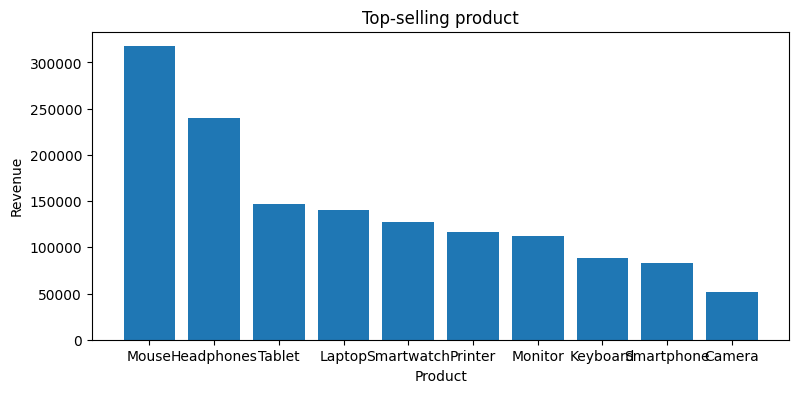

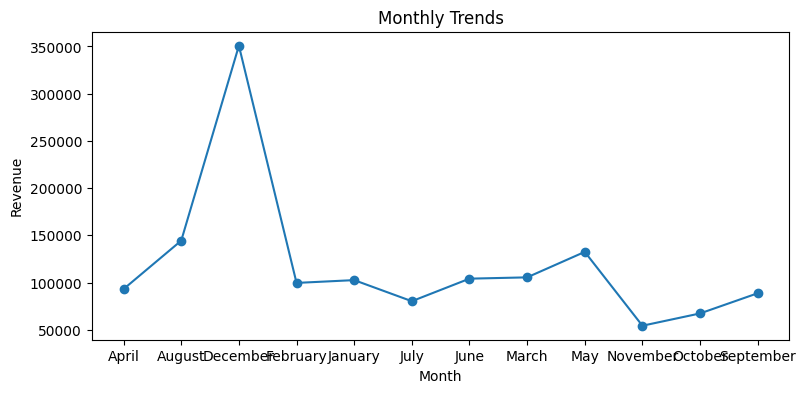

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('Data.csv')
print(df)

df=df.dropna()
df=df.drop_duplicates()
print(df)

df["Revenue"]=df["Quantity"]*df["Sales"]
print(df)

avg_revenue = np.mean(df["Revenue"])
high_revenue_orders = df[df["Revenue"] > avg_revenue]
print(high_revenue_orders)

sales_product = df.groupby("Product Name")["Revenue"].sum()
sales_product = sales_product.sort_values(ascending=False)
print(sales_product)

df["Order Date"]=pd.to_datetime(df["Order Date"],format="%d-%m-%Y",errors="coerce")
df["Month"]=df["Order Date"].dt.month_name()
monthly_revenue=df.groupby("Month")["Revenue"].sum()
print(monthly_revenue)

plt.figure(figsize=(9,4))
plt.bar(sales_product.index,sales_product.values)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Top-selling product")
plt.show()

plt.figure(figsize=(9,4))
plt.plot(monthly_revenue.index,monthly_revenue.values,marker='o')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Trends")
plt.show()